## NLP - Visualizing Embeddings

In [5]:
# We are suppose to reduce dimension from 100D to 2D 
# This will let us visually see:
# 1. similar words clustered together
# 2. Opposite words seperate 

# How we are going to reduce Dimensions?
""" 
    We will use Dimensionality Reduction:
    --Reducing the number of features while preserving important information. 
    We convert :
        10000-> 100
        100 -> 10
    Why we need to do that ?
    To solve problem of Curse of Dimensionality 

    Types of Dimensionality Reduction 
    1. Feature Selection: Remove some useless columsn
    2. Feature Extraction: Create new feature from existing columns

    PCA -- Combines features
    -- finds the direction where data varies most 
    -- these directions = Principal Components
    Instead of original features - we use these directions 
    
    Suppose user:
    height and weight are correlated
    Instead of 2 feature - PCA creates a new feature represnting both 

    How PCA works ?
    1. Standardize data 
    2. Compute convariance matrix
    3. Find eigenvectors
    4. Select top components
    5. Project data 

    Suppose we want 2 components:
    PC1 -> Most Information - 60%
    PC2 -> second most - 25%

    Limitations of PCA:
    1. Linear only
    2. Cannot capture complete shapes
    
    T-SNE - t-distributed Stochastic Beighbor Embedding
    It preserve:
    Local structure (neighbours)
    Points close in high-dim -> close in low-dim
    It converts distance into -> probabilities
    Use KL Divergence

    UMAP - Uniform manifold Approsimation & Projection
    
    

"""

' \n    We will use Dimensionality Reduction:\n    --Reducing the number of features while preserving important information. \n    We convert :\n        10000-> 100\n        100 -> 10\n    Why we need to do that ?\n    To solve problem of Curse of Dimensionality \n\n    Types of Dimensionality Reduction \n    1. Feature Selection: Remove some useless columsn\n    2. Feature Extraction: Create new feature from existing columns\n\n    PCA -- Combines features\n    -- finds the direction where data varies most \n    -- these directions = Principal Components\n    Instead of original features - we use these directions \n\n    Suppose user:\n    height and weight are correlated\n    Instead of 2 feature - PCA creates a new feature represnting both \n\n    How PCA works ?\n    1. Standardize data \n    2. Compute convariance matrix\n    3. Find eigenvectors\n    4. Select top components\n    5. Project data \n\n    Suppose we want 2 components:\n    PC1 -> Most Information - 60%\n    PC2 -> 

In [6]:
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 

In [7]:
model=api.load("glove-wiki-gigaword-100")
print("Loaded... ")

Loaded... 


In [8]:
words = [
    "king","queen","man","woman",
    "dog","cat","animal",
    "car","truck","bus","vehicle",
    "happy", "sad","joy","anger"
]

In [9]:
vector = [model[word] for word in words]

In [10]:
vector[0].shape

(100,)

In [11]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(vector)

In [12]:
reduced.shape

(15, 2)

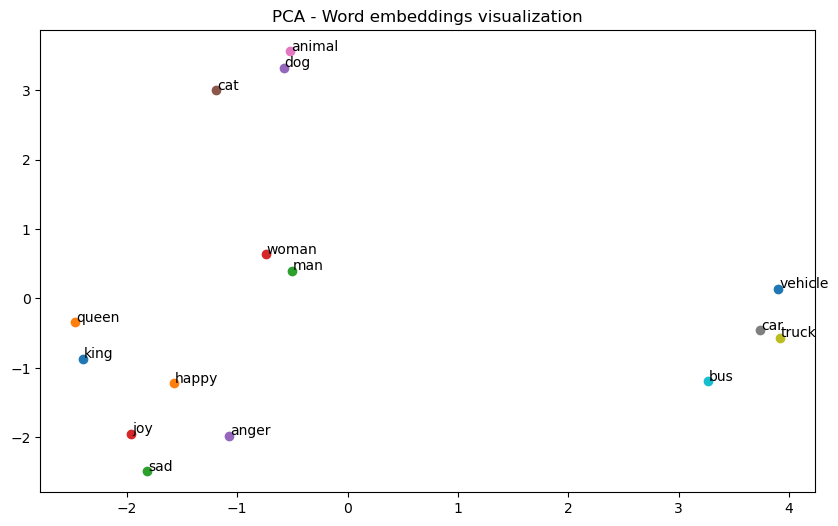

In [13]:
plt.figure(figsize=(10,6))

for i,word in enumerate(words):
    x=reduced[i][0]
    y=reduced[i][1]
    plt.scatter(x,y)
    plt.text(x+0.01,y+0.01,word)
plt.title("PCA - Word embeddings visualization")
plt.show()

In [14]:
from sklearn.manifold import TSNE 
import numpy as np

In [15]:
vector =np.array([model[word] for word in words])

In [16]:
tsne = TSNE(n_components=2, perplexity =2)
reduced = tsne.fit_transform(vector)

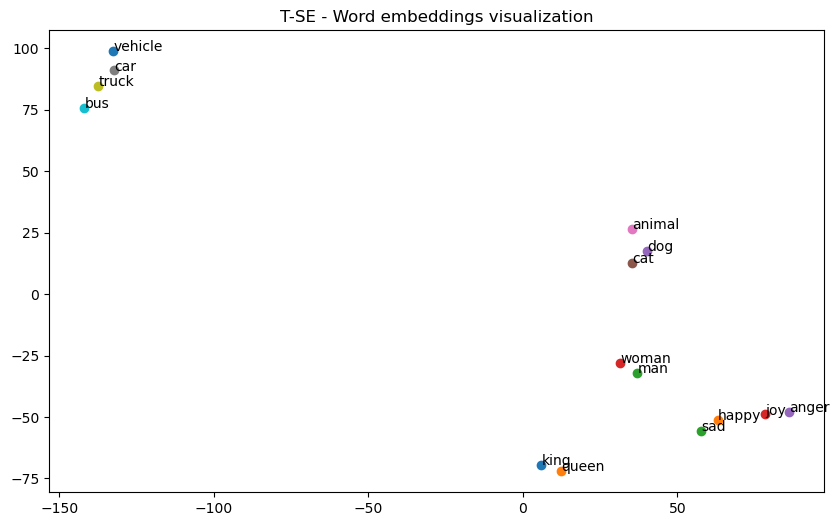

In [17]:
plt.figure(figsize=(10,6))

for i,word in enumerate(words):
    x=reduced[i][0]
    y=reduced[i][1]
    plt.scatter(x,y)
    plt.text(x+0.01,y+0.01,word)
plt.title("T-SE - Word embeddings visualization")
plt.show()